In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch; from torch import nn; from d2l import torch as d2l
if os.path.basename(os.getcwd()) == 'notes': os.chdir('..')
print('工作目录:', os.getcwd())

工作目录: d:\github\prediction


In [2]:
# ============================================================
# 从 NetCDF 读取 #0 站点 → 80/15/5 分割 → 预处理 → MLP 直接多步训练 (48步)
# 先分割再插值, 杜绝边界数据泄漏; pm_ave 保持原始量纲
# 直接多步: 过去 tau=48 步 → 一次输出未来 H=48 步 (不递归, 无误差累积)
# ============================================================
import netCDF4 as nc

def load_station(nc_path, idx=0):
    """从 NetCDF 读取指定站点, 转为带 datetime 索引的 DataFrame"""
    f = nc.Dataset(nc_path)
    t = f.variables['time'][:]
    dt = pd.Timestamp(f.variables['time'].units.split('since ')[1]) + pd.to_timedelta(t, unit='h')
    pm25 = f.variables['PM2.5'][:, idx]
    f.close()
    df = pd.DataFrame({'PM_Jingan': pm25, 'PM_US Post': pm25, 'PM_Xuhui': pm25}, index=dt)
    df.index.name = 'datetime'
    return df.resample('1h').first()

def split_and_preprocess(df, ratios=(0.80, 0.15, 0.05)):
    """分割 → 各子集独立预处理 → 返回 train/val/test"""
    n = len(df); n1 = int(n * ratios[0]); n2 = int(n * sum(ratios[:2]))
    subs = []
    for raw in [df.iloc[:n1], df.iloc[n1:n2], df.iloc[n2:]]:
        d = raw.copy()
        d['pm_ave'] = d[['PM_Jingan','PM_US Post','PM_Xuhui']].mean(axis=1)
        d['pm_ave'] = d['pm_ave'].interpolate(method='time', limit=168).ffill().bfill()
        subs.append(d)
    return subs

df_raw = load_station('data3/dataset_yrd.nc', idx=0)
df_tr, df_va, df_te = split_and_preprocess(df_raw)
print(f'训练 {len(df_tr)} | 验证 {len(df_va)} | 测试 {len(df_te)}')

# pm_ave 提取 + 标准化 (用训练集统计量)
x_tr = torch.tensor(df_tr['pm_ave'].values, dtype=torch.float32)
x_va = torch.tensor(df_va['pm_ave'].values, dtype=torch.float32)
x_te = torch.tensor(df_te['pm_ave'].values, dtype=torch.float32)
mean, std = x_tr.mean(), x_tr.std()
x_tr, x_va, x_te = (x_tr - mean) / std, (x_va - mean) / std, (x_te - mean) / std

# 直接多步特征 (向量化): 过去 tau 步 → 未来 H 步
tau, H = 48, 48
def make_feats(x, tau, H):
    n = len(x) - tau - H + 1
    feats = torch.stack([x[i:i+n] for i in range(tau)], dim=1)        # (n, tau) 输入
    labs  = torch.stack([x[tau+k:tau+k+n] for k in range(H)], dim=1)  # (n, H) 未来 H 步
    return feats, labs

ftr_tr, lab_tr = make_feats(x_tr, tau, H)
ftr_va, lab_va = make_feats(x_va, tau, H)
print(f'直接多步样本: 训练 {tuple(ftr_tr.shape)}→{tuple(lab_tr.shape)} | 验证 {tuple(ftr_va.shape)}')
train_iter = d2l.load_array((ftr_tr, lab_tr), 16, is_train=True)
val_iter   = d2l.load_array((ftr_va, lab_va), 16, is_train=False)

# MLP: Linear(tau,128) → ReLU → Linear(128,H)
def get_net():
    net = nn.Sequential(nn.Linear(tau, 128), nn.ReLU(), nn.Linear(128, H))
    net.apply(lambda m: nn.init.xavier_uniform_(m.weight) if type(m)==nn.Linear else None)
    return net

loss = nn.MSELoss(reduction='none')
def train(net, tr_it, va_it, loss, epochs, lr, wd=0.002):
    opt = torch.optim.Adam(net.parameters(), lr)
    for ep in range(epochs):
        net.train()
        for X, y in tr_it:
            opt.zero_grad()
            l = loss(net(X), y); l2 = sum((p**2).sum() for p in net.parameters())
            (l.sum() + wd * l2).backward(); opt.step()
        print(f'epoch {ep+1}, train {d2l.evaluate_loss(net,tr_it,loss):.4f}, val {d2l.evaluate_loss(net,va_it,loss):.4f}')

net = get_net()
train(net, train_iter, val_iter, loss, 20, 0.01)

训练 56102 | 验证 10519 | 测试 3507
直接多步样本: 训练 (56007, 48)→(56007, 48) | 验证 (10424, 48)


d:\conda_envs\d2l\lib\site-packages\d2l\torch.py:3179: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  self.data = [a + float(b) for a, b in zip(self.data, args)]


epoch 1, train 0.7464, val 0.3615
epoch 2, train 0.7430, val 0.3651
epoch 3, train 0.7443, val 0.3548
epoch 4, train 0.7569, val 0.3571
epoch 5, train 0.7528, val 0.3552
epoch 6, train 0.7773, val 0.4490
epoch 7, train 0.7541, val 0.3630
epoch 8, train 0.7468, val 0.3664
epoch 9, train 0.7431, val 0.3480
epoch 10, train 0.7432, val 0.3569
epoch 11, train 0.7625, val 0.3537
epoch 12, train 0.7455, val 0.3741
epoch 13, train 0.7433, val 0.3588
epoch 14, train 0.7601, val 0.4014
epoch 15, train 0.7490, val 0.3463
epoch 16, train 0.7464, val 0.3836
epoch 17, train 0.7588, val 0.3904
epoch 18, train 0.7470, val 0.3929
epoch 19, train 0.7604, val 0.3972
epoch 20, train 0.7414, val 0.3701


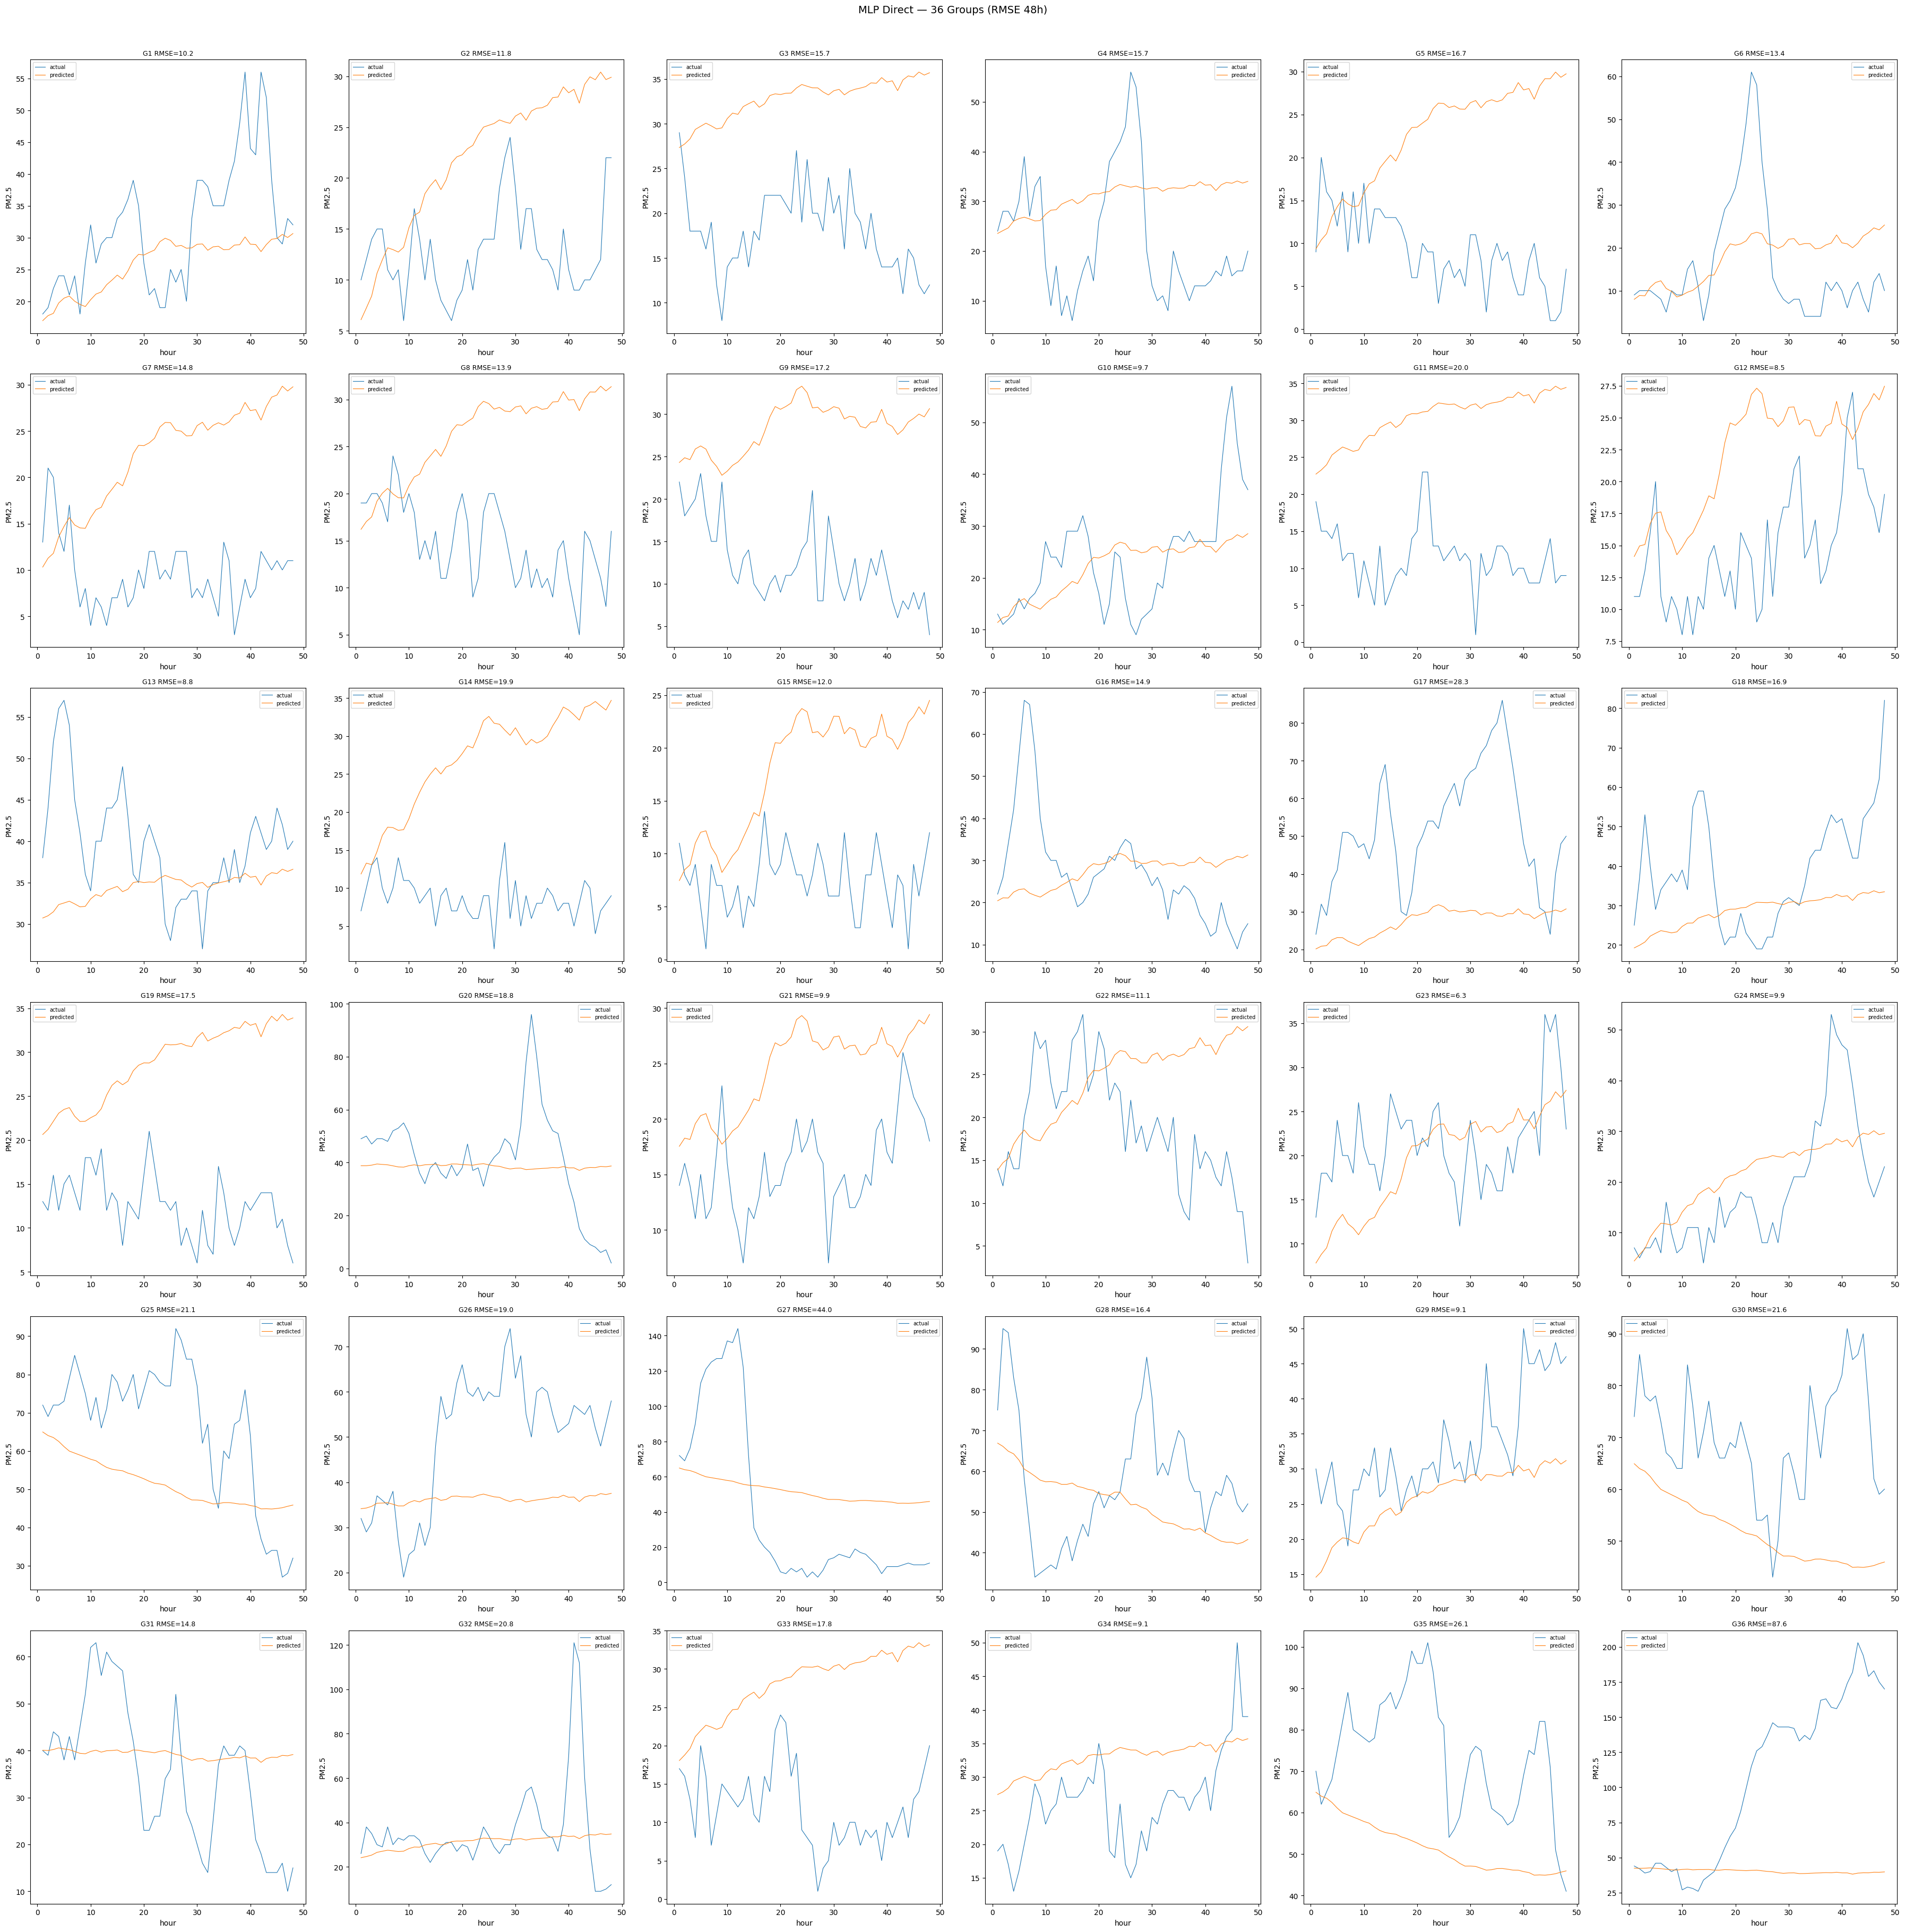


=== 36 组 RMSE 汇总 (48h | 24h) ===
  G 1:  10.24 |   7.28
  G 2:  11.77 |   8.78
  G 3:  15.70 |  13.42
  G 4:  15.68 |  12.13
  G 5:  16.69 |  10.22
  G 6:  13.43 |  13.59
  G 7:  14.78 |  11.05
  G 8:  13.90 |   9.20
  G 9:  17.17 |  14.35
  G10:   9.66 |   6.89
  G11:  20.00 |  16.60
  G12:   8.55 |   8.32
  G13:   8.85 |  11.79
  G14:  19.94 |  14.84
  G15:  11.98 |   8.04
  G16:  14.90 |  17.65
  G17:  28.31 |  23.07
  G18:  16.87 |  16.56
  G19:  17.52 |  11.71
  G20:  18.76 |   8.28
  G21:   9.87 |   8.83
  G22:  11.05 |   5.66
  G23:   6.31 |   7.01
  G24:   9.91 |   6.48
  G25:  21.13 |  19.72
  G26:  19.02 |  15.28
  G27:  43.96 |  50.72
  G28:  16.39 |  15.94
  G29:   9.14 |   7.05
  G30:  21.62 |  15.11
  G31:  14.84 |  12.95
  G32:  20.80 |   5.73
  G33:  17.76 |  11.23
  G34:   9.05 |   8.32
  G35:  26.12 |  29.98
  G36:  87.64 |  29.26

平均 RMSE(48h) = 18.04 | 参考 RMSE(24h) = 13.70


In [3]:
# ============================================================
# 36 组评估: 每组 tau=48h 上下文 → MLP 一次预测 48h, RMSE (ug/m3)
# 同时报告 48h RMSE 与前 24h RMSE (参考)
# ============================================================
N_GROUPS, N_CTX, N_PRED = 36, tau, H
STRIDE = (len(df_te) - N_CTX - N_PRED) // (N_GROUPS - 1)
actual_all = df_te['pm_ave'].values

rmses, rmses24 = [], []
fig, axes = plt.subplots(12, 3, figsize=(18, 42)); axes = axes.flatten()
for g in range(N_GROUPS):
    s = g * STRIDE
    w = x_te[s:s+tau].reshape(1, -1)                    # (1, tau) 标准化上下文
    with torch.no_grad():
        pred_std = net(w).numpy().reshape(-1)          # (H,) 直接多步输出
    preds = pred_std * std.item() + mean.item()        # 反标准化
    actual = actual_all[s+N_CTX:s+N_CTX+N_PRED]
    err2 = (preds - actual) ** 2
    rmses.append(np.sqrt(err2.mean()))                 # 48h RMSE
    rmses24.append(np.sqrt(err2[:24].mean()))          # 前 24h RMSE (参考)
    ax = axes[g]; h = np.arange(1, N_PRED+1)
    ax.plot(h, actual, lw=0.8, label='actual')
    ax.plot(h, preds, lw=0.8, label='predicted')
    ax.set_title(f'G{g+1} RMSE={rmses[-1]:.1f}', fontsize=9)
    ax.legend(fontsize=7); ax.set_xlabel('hour'); ax.set_ylabel('PM2.5')
plt.suptitle(f'MLP Direct — {N_GROUPS} Groups (RMSE 48h)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
rmses = np.array(rmses); rmses24 = np.array(rmses24)
print(f'\n=== {N_GROUPS} 组 RMSE 汇总 (48h | 24h) ===')
for g in range(N_GROUPS): print(f'  G{g+1:2d}: {rmses[g]:6.2f} | {rmses24[g]:6.2f}')
print(f'\n平均 RMSE(48h) = {rmses.mean():.2f} | 参考 RMSE(24h) = {rmses24.mean():.2f}')